# Ride-Sharing Demand & Revenue Intelligence  
## Exploratory Data Analysis (SQL + Python)

### Objective

Analyze demand patterns, revenue distribution, and behavioral trends 
using SQL for aggregations and Python for visualization

In [1]:
import duckdb 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r'C:\prerit\Projects\Ride-Sharing-Demand-Intelligence\Processed\Cleaned_yellow_tripdata_2025-01.csv')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,0.0,8.35,0,1,2,0,11.25,2.16,0.30
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,0.0,2.55,0,1,2,0,24.24,4.75,0.40
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,0.0,1.95,0,1,2,0,20.17,6.21,0.39
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,5.57,0,1,2,0,18.65,1.74,0.00
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,3.53,0,1,2,0,12.58,2.35,0.00


### Let's stablish connection for SQL

In [3]:
connection = duckdb.connect()
connection.register("taxi", df)

### Hourly demand analysis using SQL

In [4]:
query = """
select 
  pickup_hour,
  count(*) as total_trips,
  round(sum(total_amount), 2) as total_revenue,
  round(avg(fare_amount), 2) as avg_fare,
  round(avg(tip_amount), 2) as avg_tip,
  round(avg(trip_duration_min), 2) as avg_trip_duration
from taxi
group by pickup_hour
order by pickup_hour
"""

hourly_df = connection.execute(query).df()

hourly_df.head()

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration
0,0,83389,2170044.30,17.65,2.69,13.62
1,1,57518,1407829.73,16.56,2.45,12.90
2,2,38855,913749.36,15.84,2.31,12.64
3,3,24442,591407.57,16.44,2.36,12.56
4,4,16860,486334.28,20.58,2.66,14.12


## Trips by hour

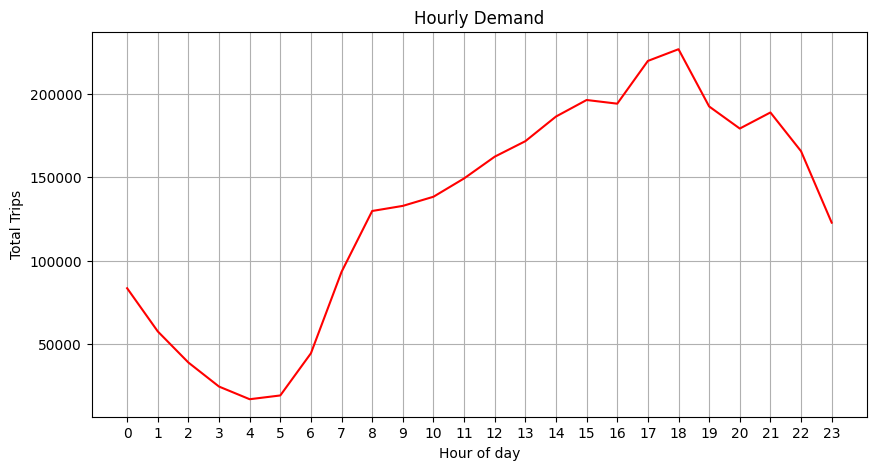

In [5]:
plt.figure(figsize=(10,5))
sns.lineplot( x="pickup_hour", y="total_trips", data=hourly_df, color="red") # line plot using seaborn
# plt.plot(hourly_df["pickup_hour"], hourly_df["total_trips"], color="red") # line plot using matplotlib.pyplot
# plt.bar(hourly_df["pickup_hour"], hourly_df["total_trips"], color="red") # bar plot using matplotlib.pyplot
plt.title("Hourly Demand")
plt.xlabel("Hour of day")
plt.ylabel("Total Trips")
plt.xticks(range(0,24))
plt.grid(True) # used to show gridlines
plt.show()

In [6]:
print("highest value for total trips :",hourly_df["total_trips"].max())
print("middle value for total trips :", hourly_df["total_trips"].median())
print("lowest value for total trips :", hourly_df["total_trips"].min())

highest value for total trips : 226665
middle value for total trips : 143723.5
lowest value for total trips : 16860


### Peak demand occurs at 6 PM (18:00) with 226,665 trips.

### The lowest demand is observed at 4 AM with 16,860 trips

## Revenue by hour

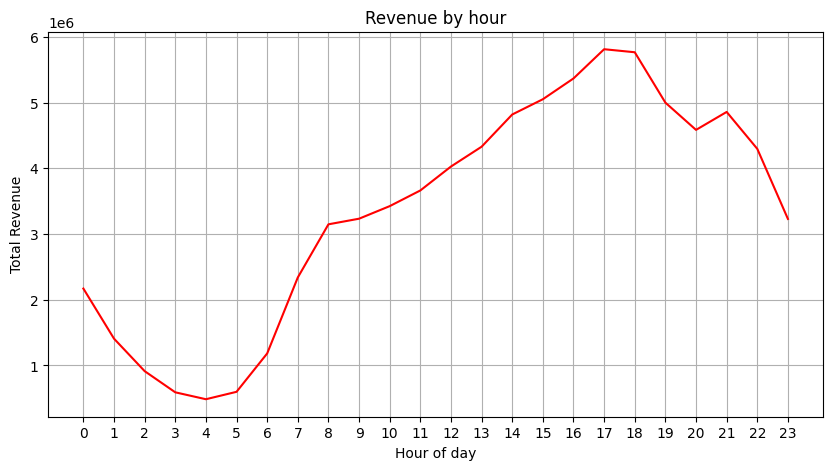

In [7]:
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_df, x="pickup_hour", y="total_revenue", color="red")
plt.title("Revenue by hour")
plt.xlabel("Hour of day")
plt.ylabel("Total Revenue")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

In [8]:
print("highest value for total revenue :",hourly_df["total_revenue"].max())
print("middle value for total revenue :", hourly_df["total_revenue"].median())
print("lowest value for total revenue :", hourly_df["total_revenue"].min())

highest value for total revenue : 5811737.99
middle value for total revenue : 3543577.385
lowest value for total revenue : 486334.28


### Highest revenue is generated at 5 PM (17:00), totaling $5.81M.

### The lowest revenue is generated at 4 AM, totaling $0.48M.

## Average revenue per trip

In [9]:
hourly_df["revenue_per_trip"] = hourly_df["total_revenue"] / hourly_df["total_trips"]


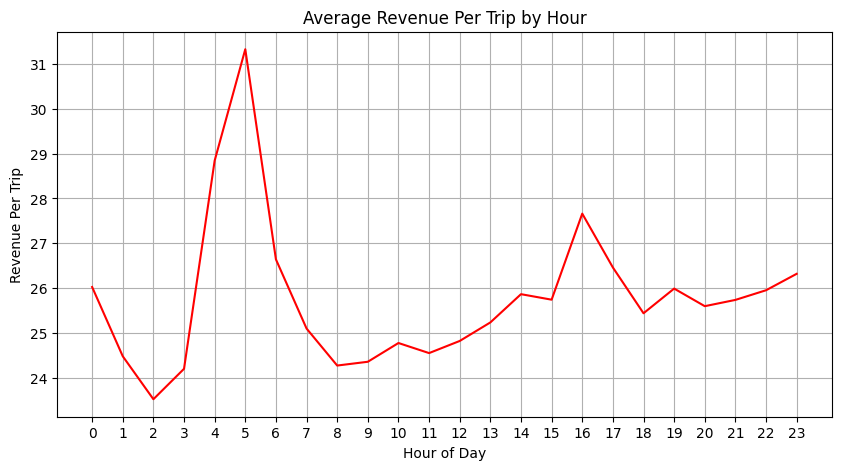

In [10]:
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_df, x="pickup_hour", y="revenue_per_trip", color="red")
plt.title("Average Revenue Per Trip by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue Per Trip")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

### Highest revenue per trip occurs at 5th hour(5 am).
### Lowest revenue per trip occurs at 2nd hour(2 am).

## Weekend VS Weekday

In [11]:
query = """
select 
    is_weekend,
    count(*) as total_trips,
    sum(total_amount) as total_revenue,
    round(avg(fare_amount), 2) as avg_fare,
    round(avg(trip_distance), 2) as avg_distance,
    round(avg(trip_duration_min), 2) as avg_duration,
    round(avg(tip_percentage), 2) as avg_tip_percentage,
    (case when is_weekend = 0 then 'Weekday' else 'Weekend' end) as day_type
from taxi
group by is_weekend
"""

weekend_df = connection.execute(query).df()
weekend_df

,is_weekend,total_trips,total_revenue,avg_fare,avg_distance,avg_duration,avg_tip_percentage,day_type
0,0,2329960,60413815.71,17.02,2.91,15.06,0.20,Weekday
1,1,802864,19879428.77,16.76,2.99,13.84,0.19,Weekend


### Total trips: Weekend VS Weekday

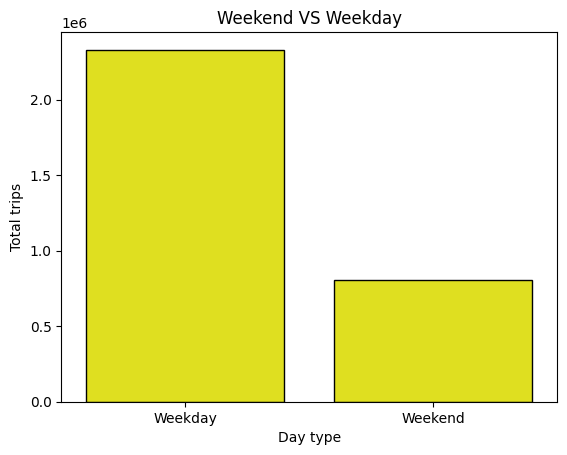

In [12]:
plt.Figure(figsize=(6,4))
sns.barplot(x="day_type", y="total_trips", data=weekend_df, color="yellow", edgecolor="black")
plt.xlabel("Day type")
plt.ylabel("Total trips")
plt.title("Weekend VS Weekday")
plt.show()

### Weekdays account for higher trip volume than weekend.
--

### Total Revenue: Weekday vs Weekend

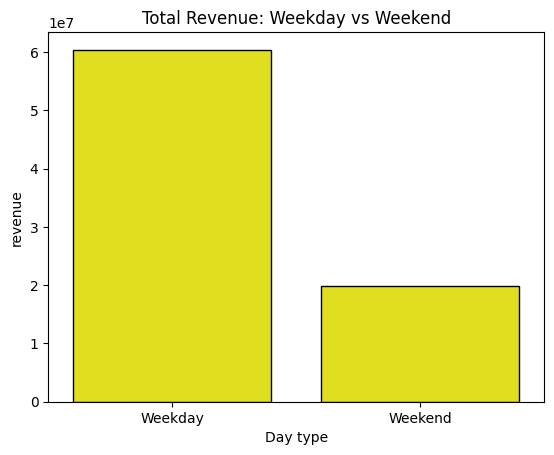

In [13]:
plt.Figure(figsize=(6,4))
sns.barplot(x="day_type", y="total_revenue", data=weekend_df, color="yellow", edgecolor="black")
plt.xlabel("Day type")
plt.ylabel("revenue")
plt.title("Total Revenue: Weekday vs Weekend")
plt.show()

### Total revenue is significantly higher on weekdays, primarily due to increased trip frequency.
--

### Average Fare: Weekday vs Weekend

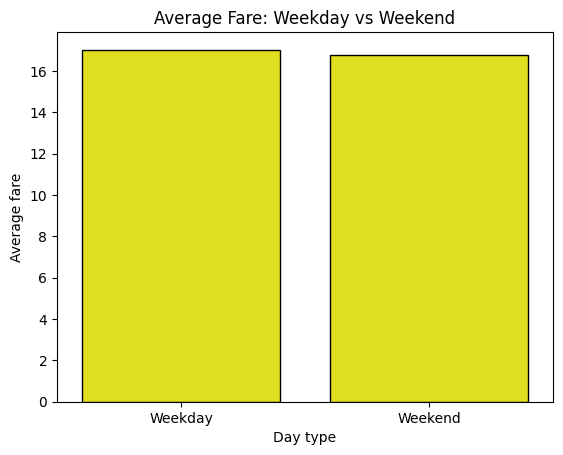

In [14]:
plt.Figure(figsize=(6,4))
sns.barplot(x="day_type", y="avg_fare", data=weekend_df, color="yellow", edgecolor="black")
plt.xlabel("Day type")
plt.ylabel("Average fare")
plt.title("Average Fare: Weekday vs Weekend")
plt.show()

### Average fare shows minimal variation between weekdays and weekends.
--

### Average trip duration: Weekday vs Weekend

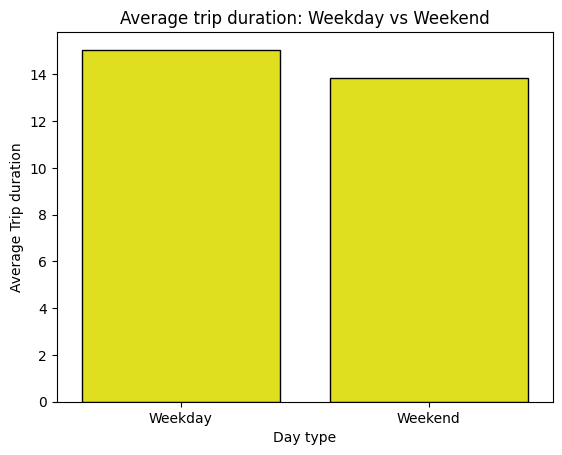

In [15]:
plt.Figure(figsize=(6,4))
sns.barplot(x="day_type", y="avg_duration", data=weekend_df, color="yellow", edgecolor="black")
plt.xlabel("Day type")
plt.ylabel("Average Trip duration")
plt.title("Average trip duration: Weekday vs Weekend")
plt.show()

### Average trip duration is slightly higher on weekdays.
--

### Average Tip %: Weekday vs Weekend

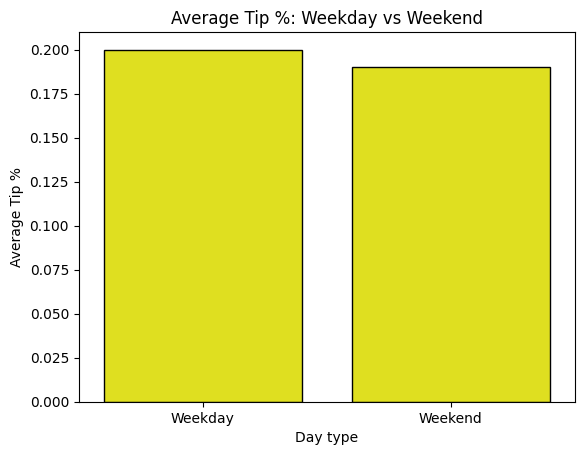

In [16]:
plt.Figure(figsize=(6,4))
sns.barplot(x="day_type", y="avg_tip_percentage", data=weekend_df, color="yellow", edgecolor="black")
plt.xlabel("Day type")
plt.ylabel("Average Tip %")
plt.title("Average Tip %: Weekday vs Weekend")
plt.show()

### Tip percentage remains relatively stable across both day types, indicating similar rider tipping behavior.
--

## Zone-level revenue intelligence

### Loading taxi zone lookup data

In [17]:
zones = pd.read_csv(r'C:\prerit\Projects\Ride-Sharing-Demand-Intelligence\Raw\taxi_zone_lookup.csv')
zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [18]:
zones.info()

<class 'pandas.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   LocationID    265 non-null    int64
 1   Borough       264 non-null    str  
 2   Zone          264 non-null    str  
 3   service_zone  263 non-null    str  
dtypes: int64(1), str(3)
memory usage: 17.0 KB


In [19]:
zones = zones.dropna()

### Let's stablish connection for zones data

In [20]:
connection.register("zones", zones)

### Top pickup zones by revenue

In [21]:
query = """
select 
  z.Borough,
  z.Zone,
  count(*) as total_trips,
  sum(t.total_amount) as total_revenue,
  round(avg(t.total_amount), 2) as avg_revenue_per_trip
from taxi t 
join zones z
on t.PULocationID = z.LocationID
group by z.Borough,z.zone
order by total_revenue desc
limit 10
"""

top_zones = connection.execute(query).df()
top_zones

,Borough,Zone,total_trips,total_revenue,avg_revenue_per_trip
0,Queens,JFK Airport,102820,7578553.90,73.71
1,Queens,LaGuardia Airport,83766,5475933.53,65.37
2,Manhattan,Midtown Center,157064,3686360.29,23.47
3,Manhattan,Upper East Side South,154071,3048923.67,19.79
4,Manhattan,Upper East Side North,146082,2962775.72,20.28
5,Manhattan,Times Sq/Theatre District,114075,2918895.11,25.59
6,Manhattan,Penn Station/Madison Sq West,111663,2642451.85,23.66
7,Manhattan,Midtown East,109892,2552986.31,23.23
8,Manhattan,Lincoln Square East,103436,2205153.95,21.32
9,Manhattan,Midtown North,88951,2088218.33,23.48


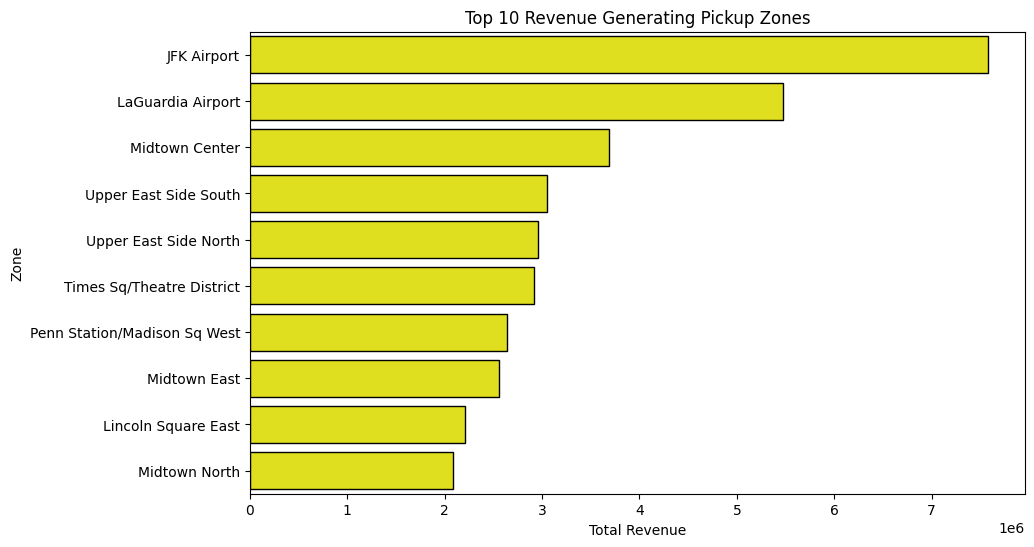

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_zones, y="Zone", x="total_revenue", color="yellow", edgecolor="black")
plt.title("Top 10 Revenue Generating Pickup Zones")
plt.xlabel("Total Revenue")
plt.ylabel("Zone")
plt.show()

### JFK Airport generates the highest revenue
### Most top zones are in manhattan 
### Airports are dominating among other zones

## Borough-level analysis

In [23]:
query = """
select 
  z.Borough,
  count(*) as total_trips,
  sum(t.total_amount) as total_revenue,
  round(avg(t.total_amount), 2) as avg_revenue_per_trip
from taxi t 
join zones z
on t.PULocationID = z.LocationID
group by z.Borough
order by total_revenue desc
"""

borough = connection.execute(query).df()
borough

,Borough,total_trips,total_revenue,avg_revenue_per_trip
0,Manhattan,2830579,6.340902e+07,22.40
1,Queens,229800,1.474698e+07,64.17
2,Brooklyn,52877,1.536212e+06,29.05
3,Bronx,12013,3.922274e+05,32.65
4,Staten Island,119,4.809970e+03,40.42
5,EWR,8,4.271800e+02,53.40


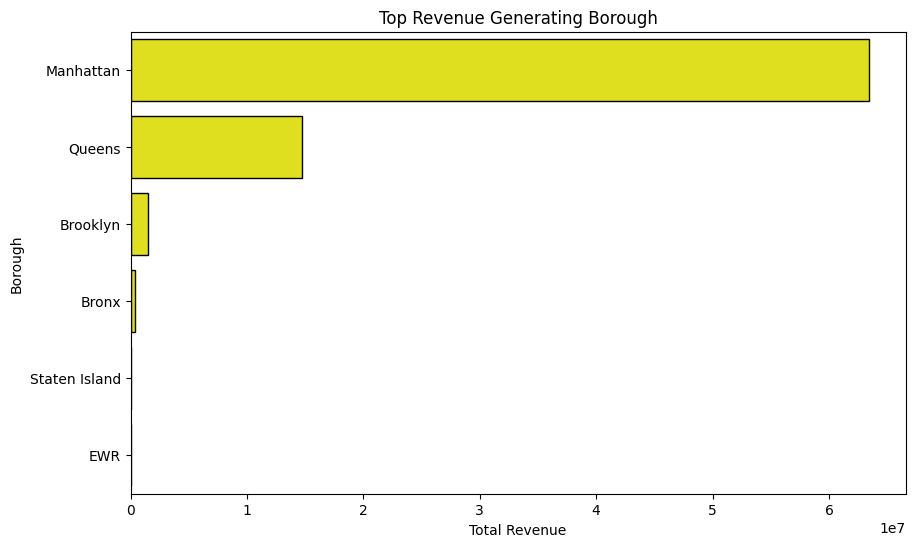

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(data=borough, y="Borough", x="total_revenue", color="yellow", edgecolor="black")
plt.title("Top Revenue Generating Borough")
plt.xlabel("Total Revenue")
plt.ylabel("Borough")
plt.show()

### Manhattan division generates most revenue out of all divisions
### Queens division has the highest average revenue per trip
### EWR division generates the lowest revenue out of all divisions

### Hourly Demand Percentile

In [43]:
hourly_df["demand_percentile"] = round(hourly_df["total_trips"].rank(pct=True) * 100, 2)
hourly_df

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration,revenue_per_trip,demand_percentile
0,0,83389,2170044.30,17.65,2.69,13.62,26.023148,29.17
1,1,57518,1407829.73,16.56,2.45,12.90,24.476333,25.00
2,2,38855,913749.36,15.84,2.31,12.64,23.516905,16.67
3,3,24442,591407.57,16.44,2.36,12.56,24.196366,12.50
4,4,16860,486334.28,20.58,2.66,14.12,28.845450,4.17
5,5,19118,599039.96,22.70,2.84,15.42,31.333819,8.33
6,6,44402,1182892.20,19.31,2.40,14.98,26.640516,20.83
7,7,93207,2339079.87,17.78,2.50,15.05,25.095539,33.33
8,8,129697,3147626.80,16.94,2.56,15.29,24.269079,41.67
9,9,132755,3233051.10,16.52,2.89,14.90,24.353517,45.83


### Surge multiplier

In [44]:
def surge_multiplier(p):
    if p < 75:
        return 1.0
    elif p < 85:
        return 1.2
    elif p < 95:
        return 1.5
    else:
        return 2.0

hourly_df["surge_multiplier"] = hourly_df["demand_percentile"].apply(surge_multiplier)

hourly_df

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration,revenue_per_trip,demand_percentile,surge_multiplier
0,0,83389,2170044.30,17.65,2.69,13.62,26.023148,29.17,1.0
1,1,57518,1407829.73,16.56,2.45,12.90,24.476333,25.00,1.0
2,2,38855,913749.36,15.84,2.31,12.64,23.516905,16.67,1.0
3,3,24442,591407.57,16.44,2.36,12.56,24.196366,12.50,1.0
4,4,16860,486334.28,20.58,2.66,14.12,28.845450,4.17,1.0
5,5,19118,599039.96,22.70,2.84,15.42,31.333819,8.33,1.0
6,6,44402,1182892.20,19.31,2.40,14.98,26.640516,20.83,1.0
7,7,93207,2339079.87,17.78,2.50,15.05,25.095539,33.33,1.0
8,8,129697,3147626.80,16.94,2.56,15.29,24.269079,41.67,1.0
9,9,132755,3233051.10,16.52,2.89,14.90,24.353517,45.83,1.0


### Surge revenue per hour

In [46]:
hourly_df["surge_revenue"] = hourly_df["total_revenue"] *hourly_df["surge_multiplier"]
hourly_df

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration,revenue_per_trip,demand_percentile,surge_multiplier,surge_revenue
0,0,83389,2170044.30,17.65,2.69,13.62,26.023148,29.17,1.0,2.170044e+06
1,1,57518,1407829.73,16.56,2.45,12.90,24.476333,25.00,1.0,1.407830e+06
2,2,38855,913749.36,15.84,2.31,12.64,23.516905,16.67,1.0,9.137494e+05
3,3,24442,591407.57,16.44,2.36,12.56,24.196366,12.50,1.0,5.914076e+05
4,4,16860,486334.28,20.58,2.66,14.12,28.845450,4.17,1.0,4.863343e+05
5,5,19118,599039.96,22.70,2.84,15.42,31.333819,8.33,1.0,5.990400e+05
6,6,44402,1182892.20,19.31,2.40,14.98,26.640516,20.83,1.0,1.182892e+06
7,7,93207,2339079.87,17.78,2.50,15.05,25.095539,33.33,1.0,2.339080e+06
8,8,129697,3147626.80,16.94,2.56,15.29,24.269079,41.67,1.0,3.147627e+06
9,9,132755,3233051.10,16.52,2.89,14.90,24.353517,45.83,1.0,3.233051e+06


### Surge (before vs after) Analysis

In [63]:
original_revenue = hourly_df["total_revenue"].sum()
surge_revenue = hourly_df["surge_revenue"].sum()

increase_percentage = round(((surge_revenue - original_revenue) / original_revenue) *100, 2).astype(str) + " %"
print("revenue before surge :", original_revenue)
print()
print("revenue after surge :", surge_revenue)
print()
print("percentage change :", increase_percentage)

revenue before surge : 80293244.48

revenue after surge : 100014570.995

percentage change : 24.56 %


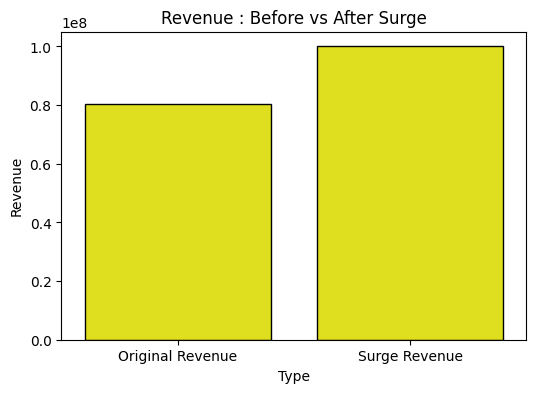

In [66]:
surge_df = pd.DataFrame({
    "Type": ["Original Revenue", "Surge Revenue"],
    "Revenue": [original_revenue, surge_revenue]
})

plt.figure(figsize=(6,4))
sns.barplot(data = surge_df, x = "Type", y = "Revenue", color = "yellow", edgecolor="black")
plt.title("Revenue : Before vs After Surge")
plt.show()